In [2]:
# import modules for use in the notebook

# handling www based requests (like APIs)
import urllib as ul

# standard Python data handling modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# working with networks
import networkx as nx

'''NetworkX - Network Analysis in Python - [https://networkx.org/documentation/stable/index.html](https://networkx.org/documentation/stable/index.html)'''

'NetworkX - Network Analysis in Python - [https://networkx.org/documentation/stable/index.html](https://networkx.org/documentation/stable/index.html)'

### Notes on file type
GML and other file structures can be used to import straight into a network object, we will do this manually here

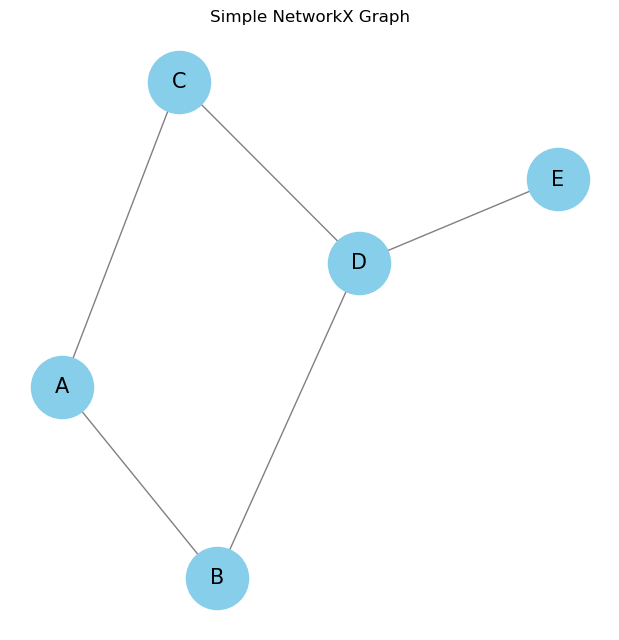

In [3]:
#create a graph
G = nx.Graph()

#add nodes to the graph
G.add_node("A")
G.add_nodes_from(["B", "C", "D", "E"])

#add edges to connect the nodes
G.add_edge("A", "B")
G.add_edges_from([("A", "C"), ("B", "D"), ("C", "D"), ("D", "E")])

#draw the graph
plt.figure(figsize=(6, 6))
nx.draw(G, with_labels=True, node_color="skyblue", edge_color="gray", node_size=2000, font_size=15) # inherits from matplot lib
plt.title("Simple NetworkX Graph")
plt.show()

##### <font color='darkblue'>Node Degree</font>

Node degree is simply the number of connections a node has. Nodes with higher degree are often called `hub` nodes because they have many connections to other members of the network.

In [14]:
#sort the genes (node names) by degree
sorted_list = sorted(G.degree(), key=lambda item: item[1] , reverse=True)

## .degree() called on graph object will give use an array of connction sizes, use lambda to get a list of counts
## Quite quick and efficient

# print out the top10 using prettytable
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Gene","Degree"]
for gene in sorted_list[:10]:
    x.add_row(gene)
print(x)

+------+--------+
| Gene | Degree |
+------+--------+
|  2   |   25   |
|  3   |   24   |
|  35  |   24   |
|  36  |   24   |
|  57  |   24   |
|  67  |   24   |
|  9   |   23   |
|  19  |   23   |
|  69  |   23   |
|  71  |   23   |
+------+--------+


##### <font color='darkblue'>Closeness Centrality</font>
This is a measure of how close a node is to the centre of the network. The closer a node is to the centre the shorter its path to all other nodes and hence its more likely to be representative of the network

In [5]:
# sort the genes (node names) by proximity to center
sorted_list = sorted(nx.closeness_centrality(G).items(), key=lambda item: item[1] , reverse=True) ## NetworkX implements closeness centrality

# print out the top10 using prettytable
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Gene","Closeness"]
for gene in sorted_list[:10]:
    x.add_row(gene)
print(x)

## THe results makes sense as to get to E, we must pass through D so that results makes sense


+------+--------------------+
| Gene |     Closeness      |
+------+--------------------+
|  D   |        0.8         |
|  B   | 0.6666666666666666 |
|  C   | 0.6666666666666666 |
|  A   | 0.5714285714285714 |
|  E   |        0.5         |
+------+--------------------+


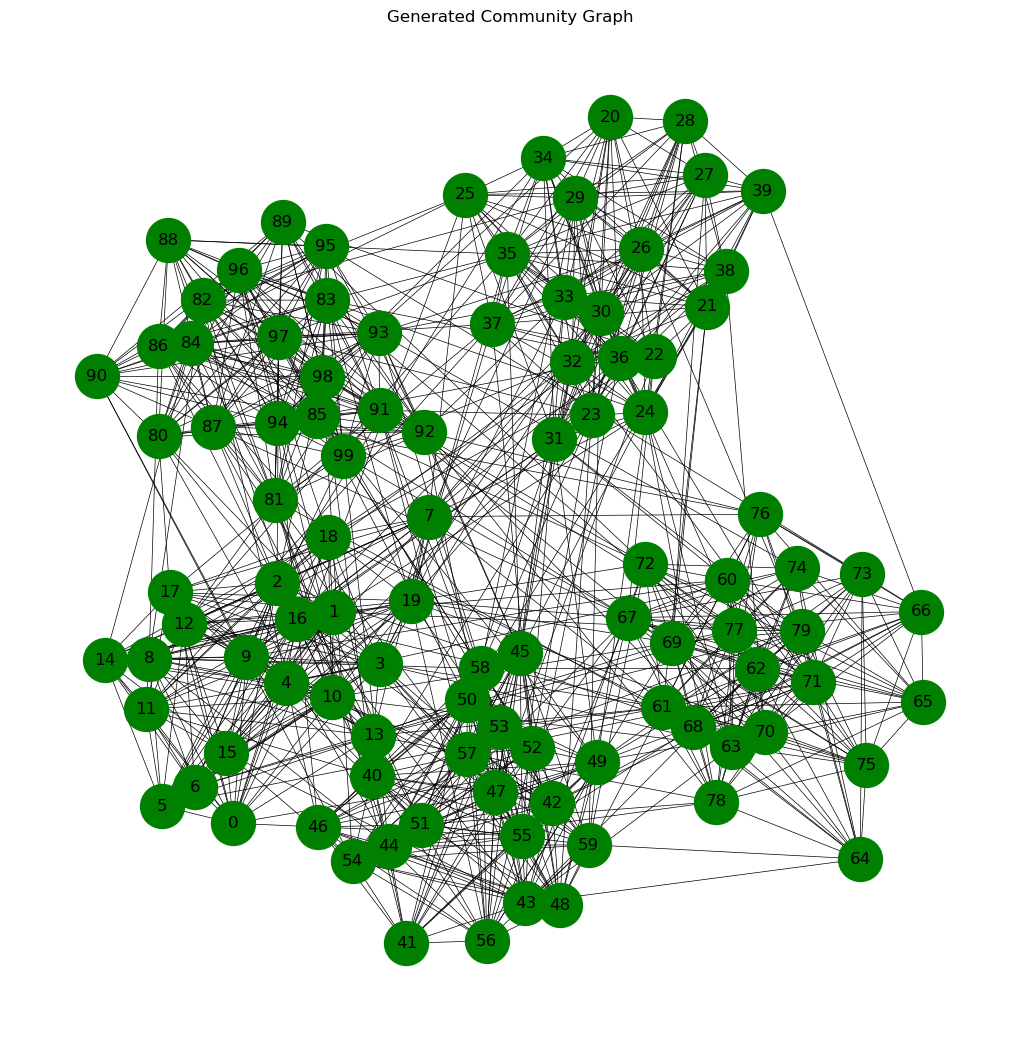

In [ ]:
# lets generate a graph with 5 clusters so we can play with clustering algorithms

# Parameters
num_clusters = 5             # Number of clusters
nodes_per_cluster = 20       # Number of nodes per cluster
p_intra = 0.8                # Probability of edge within clusters - likelihood of connections between clusters
p_inter = 0.05               # Probability of edge between clusters

# We may want to create netorks by simulation with certain properties to test an algorithm of interest for performance

# define the sizes of each cluster
sizes = [nodes_per_cluster] * num_clusters

# define the connection probabilities matrix
# p_intra is the probability within clusters, p_inter is between clusters
probs = [[p_intra if i == j else p_inter for j in range(num_clusters)] for i in range(num_clusters)]

# generate the graph using the stochastic block model
G = nx.stochastic_block_model(sizes, probs, seed=42) ## sample a network structure
## We set the 

# draw the graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)
nx.draw(G, pos, node_color="green", with_labels=True, node_size=1000, font_size=12, width=0.5)
plt.title("Generated Community Graph");

## We may want to have different levels of hubs, or bridgeness etc.
## We can evaluate performance on the ground truth of which node belongs to which clusters

##### <font color='darkblue'>Clustering Coefficient</font>
The clustering coefficient is a measure which combines centrality and degree. It measures the number of triangles a node can form ('the friend of my friend is my friend'). If a node has more common friends with other nodes it more likely to representative of the network

In [7]:
# sort the genes (node names) by clustering coefficient
sorted_list = sorted(nx.clustering(G).items(), key=lambda item: item[1] , reverse=True)

## Centralised in clustered genes are of interest and you can get clustering measure
# print out the top10 using prettytable
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Gene","Clustering"]
for gene in sorted_list[:5]:
    x.add_row(gene)
print(x)

+------+--------------------+
| Gene |     Clustering     |
+------+--------------------+
|  28  | 0.7833333333333333 |
|  41  | 0.7583333333333333 |
|  95  | 0.7581699346405228 |
|  5   |        0.75        |
|  6   | 0.7333333333333333 |
+------+--------------------+


##### <font color='darkblue'>Clustering the Network</font>

In [16]:
# we're going to cluster the networkx modularity clustering algorithm
communities = nx.algorithms.community.modularity_max.greedy_modularity_communities(G)

# print the number of communities
print('The network has '+str(len(communities))+' communities.\n')

# create sub-grpahs for each community
subgraphs = []
for community in communities:
    subgraphs.append(G.subgraph(community))
    
# print the number of nodes in each community
for i, subgraph in enumerate(subgraphs):
    print('Community '+str(i+1)+' has '+str(subgraph.number_of_nodes())+' nodes.')

# There is a large suite of clusterting suites and functionality in network k, this one uses tehe modularity maximisation

## THis is a probabilistic mmodel, does not get 20 in all clusters

The network has 5 communities.

Community 1 has 22 nodes.
Community 2 has 20 nodes.
Community 3 has 20 nodes.
Community 4 has 19 nodes.
Community 5 has 19 nodes.


##### <font color='darkblue'>Plot the Graph with Clusters Coloured</font>

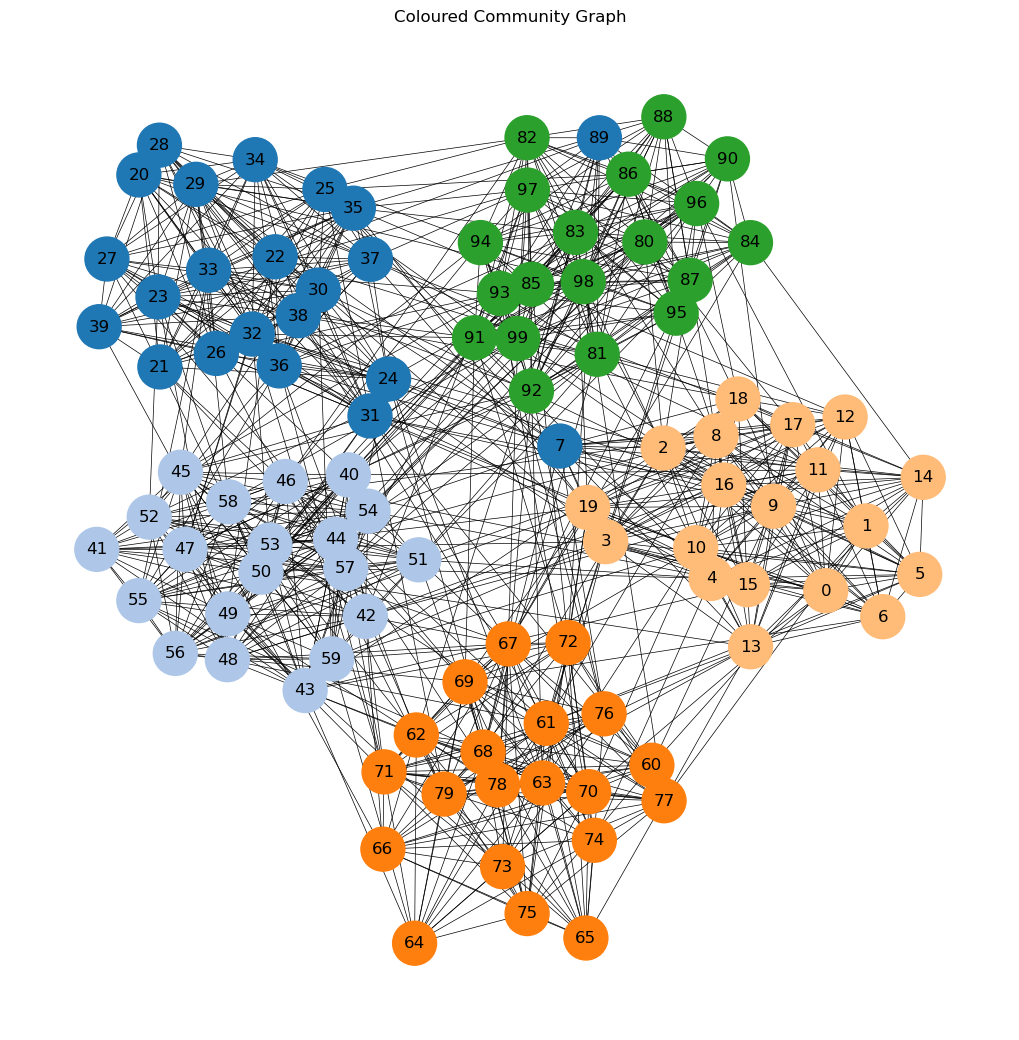

In [ ]:
# create a dict with the gene_id as key and community membership list as value
communityDict = dict()

# loop through the communities
for i, community in enumerate(communities):
    # loop through the diseases in the community
    for node_id in community:
        # add the disease and community to the dictionary
        communityDict[node_id] = i

# plot the graph with the communities coloured
# create a list as long as the number of communities in the graph, use a pallette of colours and generate a list of colours
communityColours = plt.cm.tab20.colors[:len(communities)]

# create a list of the node colours
nodeColours = [communityColours[communityDict[node]] for node in G.nodes()]

# create a list of the node labels
nodeLabels = {node:node for node in G.nodes()}

# set the figure size
plt.figure(figsize=(10,10))

# choose a layout
pos = nx.spring_layout(G)
nx.draw(G, pos, node_color=nodeColours, with_labels=True, node_size=1000, font_size=12, width=0.5)
plt.title("Coloured Community Graph");

## You can get cluster misclassification as seen below
##

### Outcomes
Used to get teeth stuck into explporing networks